In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

Some of the information in this workbook comes from Python Data Science Handbook by Jake VanderPlas, but with modifications

In [2]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60, resize=1)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 125, 94)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(faces.data, faces.target)

In [4]:
model = SVC(kernel='linear', C=2.0)
%time model.fit(X_train, y_train)
%time print(model.score(X_test, y_test))

CPU times: user 55.1 s, sys: 16.1 s, total: 1min 11s
Wall time: 8.02 s
0.8249258160237388
CPU times: user 17 s, sys: 1.4 s, total: 18.4 s
Wall time: 2.02 s


In [5]:
model = GaussianNB()
%time model.fit(X_train,y_train)
%time print(model.score(X_test,y_test))

CPU times: user 184 ms, sys: 67.5 ms, total: 251 ms
Wall time: 32.9 ms
0.39762611275964393
CPU times: user 63.1 ms, sys: 376 ms, total: 439 ms
Wall time: 47.3 ms


In [6]:
model = KNeighborsClassifier(n_neighbors=5)
%time model.fit(X_train, y_train.ravel())
%time print(model.score(X_test, y_test))

CPU times: user 5.66 ms, sys: 18.7 ms, total: 24.4 ms
Wall time: 2.86 ms
0.5578635014836796
CPU times: user 985 ms, sys: 562 ms, total: 1.55 s
Wall time: 431 ms


In [7]:
faces = fetch_lfw_people(min_faces_per_person=60, resize=0.5)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(faces.data, faces.target)

In [9]:
model = SVC(kernel='linear', C=2.0)
%time model.fit(X_train, y_train)
%time print(model.score(X_test, y_test))

CPU times: user 563 ms, sys: 8.98 ms, total: 572 ms
Wall time: 574 ms
0.8041543026706232
CPU times: user 138 ms, sys: 1.7 ms, total: 139 ms
Wall time: 140 ms


In [10]:
model = GaussianNB()
%time model.fit(X_train,y_train)
%time print(model.score(X_test,y_test))

CPU times: user 6.13 ms, sys: 3.06 ms, total: 9.18 ms
Wall time: 8.18 ms
0.42433234421364985
CPU times: user 7.06 ms, sys: 4.74 ms, total: 11.8 ms
Wall time: 11.8 ms


In [11]:
model = KNeighborsClassifier(n_neighbors=5)
%time model.fit(X_train, y_train.ravel())
%time print(model.score(X_test, y_test))

CPU times: user 1.17 ms, sys: 531 μs, total: 1.7 ms
Wall time: 969 μs
0.5252225519287834
CPU times: user 58.1 ms, sys: 13.9 ms, total: 72 ms
Wall time: 30.1 ms


In [12]:
model = SVC(kernel='rbf',gamma='scale')
%time model.fit(X_train, y_train)
%time print(model.score(X_test, y_test))

CPU times: user 842 ms, sys: 5.27 ms, total: 848 ms
Wall time: 846 ms
0.7062314540059347
CPU times: user 295 ms, sys: 2.2 ms, total: 297 ms
Wall time: 309 ms


In [13]:
gamma_range = np.logspace(-9, 3, 13)

In [14]:
gamma_range

array([1.e-09, 1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02,
       1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])

In [15]:
param_grid = [
  {'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], 'kernel': ['linear']},
  {'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], 'gamma': ['scale'], 'kernel': ['rbf']},
 ]
model = GridSearchCV(SVC(), param_grid, verbose=4)


In [16]:
param_grid

[{'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], 'kernel': ['linear']},
 {'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
  'gamma': ['scale'],
  'kernel': ['rbf']}]

In [17]:
model.fit(X_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END ...........C=0.0001, kernel=linear;, score=0.389 total time=   0.7s
[CV 2/5] END ...........C=0.0001, kernel=linear;, score=0.391 total time=   0.7s
[CV 3/5] END ...........C=0.0001, kernel=linear;, score=0.386 total time=   0.6s
[CV 4/5] END ...........C=0.0001, kernel=linear;, score=0.386 total time=   0.7s
[CV 5/5] END ...........C=0.0001, kernel=linear;, score=0.386 total time=   0.7s
[CV 1/5] END ............C=0.001, kernel=linear;, score=0.394 total time=   0.6s
[CV 2/5] END ............C=0.001, kernel=linear;, score=0.391 total time=   0.7s
[CV 3/5] END ............C=0.001, kernel=linear;, score=0.396 total time=   0.6s
[CV 4/5] END ............C=0.001, kernel=linear;, score=0.396 total time=   0.6s
[CV 5/5] END ............C=0.001, kernel=linear;, score=0.396 total time=   0.6s
[CV 1/5] END .............C=0.01, kernel=linear;, score=0.690 total time=   0.6s
[CV 2/5] END .............C=0.01, kernel=linear;

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.0001, 0.001, ...], 'kernel': ['linear']}, {'C': [0.0001, 0.001, ...], 'gamma': ['scale'], 'kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;

RBF kernel has very poor performance if we don't set gamma to scale. 

In [18]:
model.best_score_

0.8407745208018339

In [19]:
model.best_estimator_

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


If you look at the scores, there was very little difference between all the different Cs and linear

Looking at the Breast Cancer Dataset

In [20]:
model.score(X_test,y_test)

0.8100890207715133

In [21]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
cancer = load_breast_cancer()

In [22]:
X = cancer.data

PCA usually likes things to be normalised

https://www.researchgate.net/post/Is-it-necessary-to-normalize-data-before-performing-principle-component-analysis

The cancer data from before (kNN, remember I said to use standardscaler then) should certainly have some scaling beforehand

We should be selecting hyperparameters by cross-validation but I'm being lazy here as cross-validation is not the point of today's lecture

In [23]:
scale = StandardScaler()
pca = PCA(5)
X_pca = pca.fit_transform(scale.fit_transform(X))

In [24]:
X_pca.shape

(569, 5)

In [25]:
X.shape

(569, 30)

In [26]:
pca.explained_variance_ratio_

array([0.44272026, 0.18971182, 0.09393163, 0.06602135, 0.05495768])

In [27]:
pca.explained_variance_ratio_.sum()

0.8473427431680725

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, cancer.target, random_state=42)

Without Any Reduction in features

(we need to do the Standard Scaler as part of the model)

In [29]:
from sklearn.model_selection import cross_val_score

In [30]:
model = make_pipeline(StandardScaler(), SVC(kernel='linear', C=2))
cross_val_score(model, X_train, y_train).mean()

0.969466484268126

In [31]:
model = make_pipeline(StandardScaler(), SVC(kernel='linear', C=2))
%time model.fit(X_train, y_train)
%time print(model.score(X_test, y_test))

CPU times: user 9.08 ms, sys: 961 μs, total: 10 ms
Wall time: 2.85 ms
0.972027972027972
CPU times: user 1.72 ms, sys: 57 μs, total: 1.78 ms
Wall time: 877 μs


With Reduction to only 5 features

(we already used StandardScaler when making X_pca so no need again)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, cancer.target, random_state=42)

In [33]:
X_train.shape

(426, 5)

In [34]:
model = SVC(kernel='linear', C=2)
cross_val_score(model, X_train, y_train).mean()

0.962435020519836

Not as good, but not far off validation scores

In [35]:
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.986013986013986

The test score was actually better for the PCA (this is not usual)

Ok, back to the faces

In [36]:
faces = fetch_lfw_people(min_faces_per_person=60, resize=1)
X_train, X_test, y_train, y_test = train_test_split(faces.data, faces.target)

In [37]:
model = SVC(kernel='linear', C=2.0)
%time model.fit(X_train, y_train)
%time print(model.score(X_test, y_test))

CPU times: user 48.5 s, sys: 10.3 s, total: 58.8 s
Wall time: 6.66 s
0.827893175074184
CPU times: user 11.3 s, sys: 3.71 s, total: 15 s
Wall time: 1.61 s


In [38]:
model = make_pipeline(
    PCA(250),
    SVC(kernel='linear', C=2.0)
)
%time model.fit(X_train, y_train)
%time print(model.score(X_test, y_test))

CPU times: user 35.1 s, sys: 4.81 s, total: 39.9 s
Wall time: 4.23 s
0.8130563798219584
CPU times: user 334 ms, sys: 8.87 ms, total: 343 ms
Wall time: 38.9 ms


In [39]:
model = make_pipeline(
    StandardScaler(),
    PCA(250),
    SVC(kernel='linear', C=2.0)
)
%time model.fit(X_train, y_train)
%time print(model.score(X_test, y_test))

CPU times: user 37.8 s, sys: 4.08 s, total: 41.9 s
Wall time: 4.48 s
0.8338278931750742
CPU times: user 420 ms, sys: 43.1 ms, total: 463 ms
Wall time: 54.6 ms


In the test set, very slight improvement by using standardscaler, usually you would not use standardscaler on image data although PCA sometimes performs better with normalised data as shown in a previous link

Ok, let's be a bit better and use cross-validation scores to compare these

We should be using gridsearchcv to choose C etc but again, this is not the point of today's lecture

In [40]:
model = SVC(kernel='linear', C=2.0)

In [41]:
cross_val_score(model, X_train, y_train, n_jobs=-1, verbose=4).mean()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[CV] END ................................ score: (test=0.782) total time=   3.7s
[CV] END ................................ score: (test=0.847) total time=   3.8s
[CV] END ................................ score: (test=0.808) total time=   3.8s
[CV] END ................................ score: (test=0.812) total time=   3.8s
[CV] END ................................ score: (test=0.837) total time=   3.8s


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    7.3s remaining:   11.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    7.4s finished


0.8170218992342585

In [42]:
model = make_pipeline(
    StandardScaler(),
    SVC(kernel='linear', C=2.0)
)

In [43]:
cross_val_score(model, X_train, y_train, n_jobs=-1, verbose=4).mean()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[CV] END ................................ score: (test=0.847) total time=   3.6s
[CV] END ................................ score: (test=0.797) total time=   3.6s
[CV] END ................................ score: (test=0.871) total time=   3.7s


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    3.7s remaining:    5.5s


[CV] END ................................ score: (test=0.803) total time=   3.2s
[CV] END ................................ score: (test=0.842) total time=   3.2s


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.0s finished


0.8318782617177973

In [44]:
model = make_pipeline(
    StandardScaler(),
    PCA(250),
    SVC(kernel='linear', C=2.0)
)
cross_val_score(model, X_train, y_train, n_jobs=-1, verbose=4).mean()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[CV] END ................................ score: (test=0.837) total time=   1.0s
[CV] END ................................ score: (test=0.842) total time=   1.0s
[CV] END ................................ score: (test=0.861) total time=   1.0s


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    1.1s remaining:    1.7s


[CV] END ................................ score: (test=0.803) total time=   0.9s
[CV] END ................................ score: (test=0.777) total time=   1.0s


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.3s finished


0.8239574696385896

In [45]:
model = make_pipeline(
    PCA(250),
    SVC(kernel='linear', C=2.0)
)
cross_val_score(model, X_train, y_train, n_jobs=-1, verbose=4).mean()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[CV] END ................................ score: (test=0.837) total time=   0.9s
[CV] END ................................ score: (test=0.832) total time=   1.0s
[CV] END ................................ score: (test=0.802) total time=   1.0s
[CV] END ................................ score: (test=0.808) total time=   1.0s
[CV] END ................................ score: (test=0.772) total time=   1.0s


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    1.0s remaining:    1.5s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.0s finished


0.8100912061649514

In [46]:
model = make_pipeline(
    PCA(250),
    SVC(kernel='linear', C=2.0)
)
%time model.fit(X_train, y_train)
%time print(model.score(X_test, y_test))

CPU times: user 36.3 s, sys: 4.26 s, total: 40.6 s
Wall time: 4.29 s
0.8160237388724035
CPU times: user 284 ms, sys: 30.2 ms, total: 314 ms
Wall time: 36.1 ms


The difference between the cross-validation score for without PCA and with PCA is very small. But look at the time differences

Let's look at what the terms actually mean

In [47]:
pca = PCA(250)
X_pca = pca.fit_transform(X_train)
pca.explained_variance_ratio_

array([2.0861501e-01, 1.2998642e-01, 6.7687728e-02, 5.8921020e-02,
       4.3895502e-02, 2.7423026e-02, 2.3460347e-02, 2.0027256e-02,
       1.7865313e-02, 1.7114235e-02, 1.4116105e-02, 1.3736181e-02,
       1.1565205e-02, 1.0553620e-02, 9.6678855e-03, 9.2163412e-03,
       8.8491980e-03, 8.2626790e-03, 7.8841206e-03, 6.9673117e-03,
       6.5344665e-03, 6.2343911e-03, 5.5997488e-03, 5.4329052e-03,
       5.1930593e-03, 5.0115539e-03, 4.7662146e-03, 4.5630680e-03,
       4.4136187e-03, 4.0305573e-03, 3.8945591e-03, 3.7015562e-03,
       3.5796743e-03, 3.5703324e-03, 3.3806472e-03, 3.3107579e-03,
       3.2250748e-03, 3.1302606e-03, 3.0342350e-03, 2.8697446e-03,
       2.8164207e-03, 2.7324131e-03, 2.7160165e-03, 2.5410678e-03,
       2.4817528e-03, 2.4530047e-03, 2.4122915e-03, 2.3737538e-03,
       2.2549001e-03, 2.2237026e-03, 2.1251950e-03, 2.1190066e-03,
       2.0778885e-03, 2.0503439e-03, 2.0427536e-03, 1.9570470e-03,
       1.8881295e-03, 1.8635716e-03, 1.8350621e-03, 1.7609441e

In [48]:
sum(pca.explained_variance_ratio_)

0.9624188502784818

The first 250 terms are giving us approximately 96% of all the variance in the data.

11750 -> 250 is a big reduction and you can see the speed above

It may not be as accurate, but depending on the data, maybe we need speed more so than complete accuracy

Let's see what happens to some faces

In [49]:
pca = model.named_steps['pca']
img_orig = X_test[0]
img_trans = pca.inverse_transform(pca.transform([img_orig]))[0]

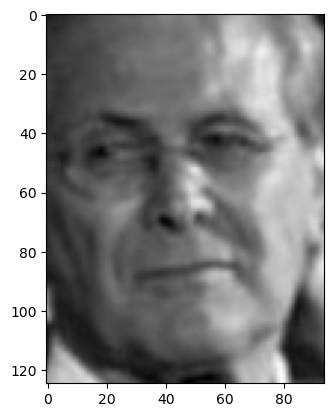

In [50]:
plt.imshow(img_orig.reshape(125,94), cmap="gray")

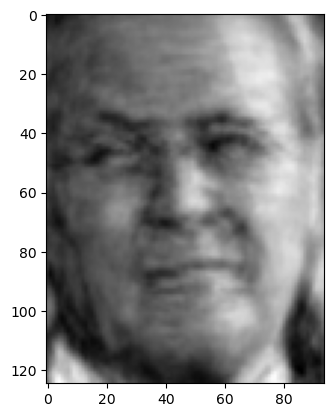

In [51]:
plt.imshow(img_trans.reshape(125,94), cmap="gray")

In [52]:
pca = model.named_steps['pca']
img_orig = X_test[30]
img_trans = pca.inverse_transform(pca.transform([img_orig]))[0]

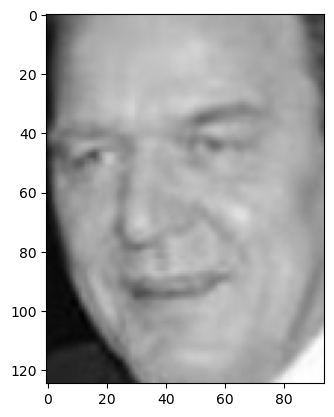

In [53]:
plt.imshow(img_orig.reshape(125,94), cmap="gray")

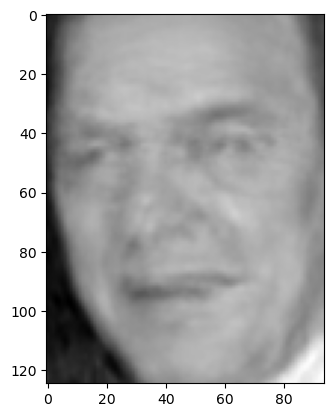

In [54]:
plt.imshow(img_trans.reshape(125,94), cmap="gray")

In [55]:
pca.components_.shape

(250, 11750)

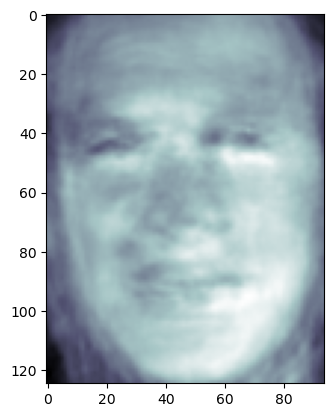

In [56]:
plt.imshow(pca.components_[0].reshape(125,94), cmap='bone')

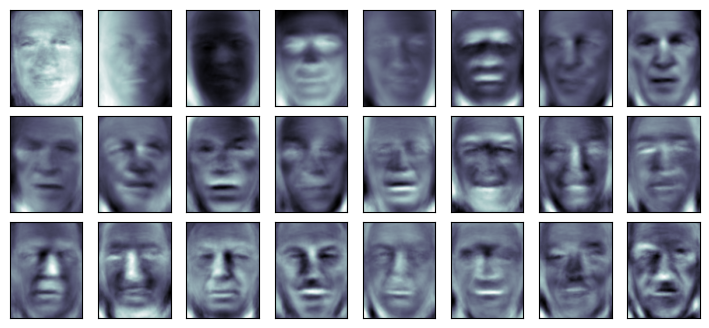

In [57]:
fig, axes = plt.subplots(3, 8, figsize=(9, 4),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(125, 94), cmap='bone')



In [58]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

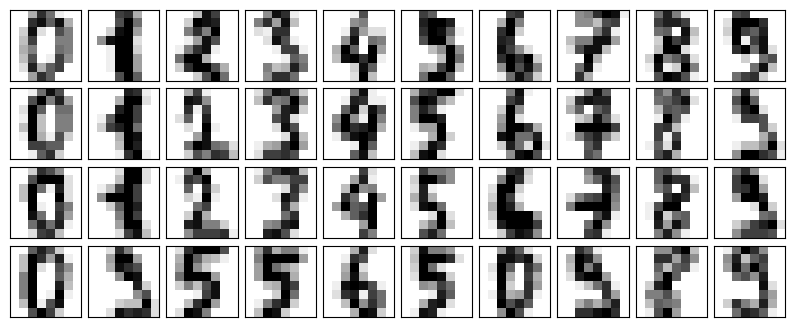

In [59]:
def plot_digits(data):
    fig, axes = plt.subplots(4, 10, figsize=(10, 4),
                             subplot_kw={'xticks':[], 'yticks':[]},
                             gridspec_kw=dict(hspace=0.1, wspace=0.1))
    for i, ax in enumerate(axes.flat):
        ax.imshow(data[i].reshape(8, 8),
                  cmap='binary', interpolation='nearest',
                  clim=(0, 16))
plot_digits(digits.data)



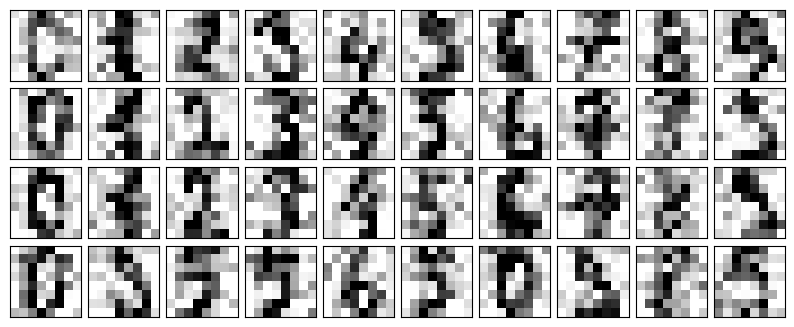

In [60]:
np.random.seed(42)
noisy = np.random.normal(digits.data, 4)
plot_digits(noisy)

In [61]:
pca = PCA(0.50).fit(noisy)
pca.n_components_

12

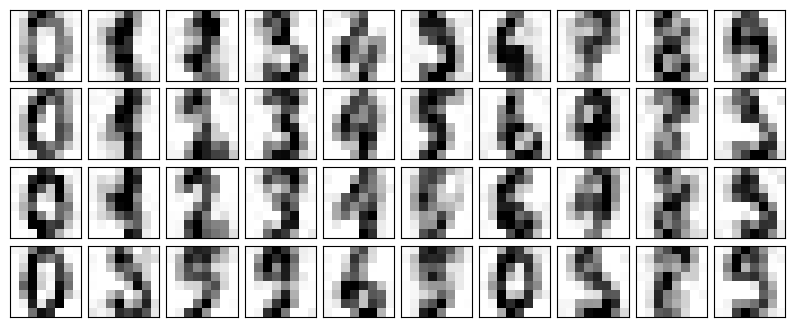

In [62]:
components = pca.transform(noisy)
filtered = pca.inverse_transform(components)
plot_digits(filtered)